# VolumeMind - Demand Forecasting Model
### Proyek VolumeMate - Team Computer Sigma (TechnoScape 2026)

Notebook ini dirancang untuk:
1. **Pembersihan Data (Data Cleaning)**: Menangani nilai curah hujan yang tidak valid (`-1`).
2. **Analisis Data Eksploratif (EDA)**: Menganalisis tren musiman kebutuhan pupuk.
3. **Pelatihan Model**: Melatih model `GradientBoostingRegressor` yang dioptimasi untuk mencegah overfitting.
4. **Evaluasi Model & Cek Overfitting**: Membandingkan skor latih vs skor uji, melakukan validasi silang runtun waktu (*Time-Series Cross-Validation*), dan memplot Kurva Pembelajaran (*Learning Curve*).
5. **Penyimpanan Model**: Mengekspor model pipeline agar siap digunakan di backend REST API microservice.

## 1. Import Libraries & Setup Lingkungan Kerja

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, learning_curve
import joblib

# Setup style visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 2. Memuat Dataset

In [2]:
try:
    from google.colab import files
    print('Silakan unggah berkas \'volumemate_dataset_updated.csv\':')
    uploaded = files.upload()
    dataset_path = 'volumemate_dataset_updated.csv'
except ImportError:
    dataset_path = 'volumemate_dataset_updated.csv'
    print('Berjalan secara lokal. Pastikan file csv berada di folder yang sama dengan notebook ini.')

# Membaca dataset
df = pd.read_csv(dataset_path)
print('Sukses! Total data:', df.shape[0], 'baris,', df.shape[1], 'kolom.')
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month

df.head()

Berjalan secara lokal. Pastikan file csv berada di folder yang sama dengan notebook ini.
Sukses! Total data: 360 baris, 7 kolom.


,tanggal,id_koperasi,jenis_pupuk,curah_hujan_mm,musim_tanam,luas_lahan_hektar,volume_kebutuhan_kg,tahun,bulan
0,2021-01-01,Koperasi Sumber Makmur,Pupuk Urea Granul,258,Rendengan,500,40471,2021,1
1,2021-01-01,Koperasi Sumber Makmur,Pupuk NPK Phonska,258,Rendengan,500,24838,2021,1
2,2021-01-01,Koperasi Sumber Makmur,Pupuk SP-36 Super,258,Rendengan,500,12047,2021,1
3,2021-01-01,Koperasi Tani Jaya,Pupuk Urea Granul,259,Rendengan,300,23584,2021,1
4,2021-01-01,Koperasi Tani Jaya,Pupuk NPK Phonska,259,Rendengan,300,14932,2021,1


## 3. Pembersihan Data (Data Cleaning)
Ada nilai curah hujan sebesar `-1` yang menandakan data rusak atau kosong. Kita memperbaikinya dengan mengganti nilai `-1` tersebut dengan rata-rata curah hujan bulanan yang valid.

In [3]:
# Mengecek baris data dengan curah hujan kotor (-1)
dirty_data = df[df['curah_hujan_mm'] == -1]
print('Jumlah data curah hujan bernilai -1:', len(dirty_data))
dirty_data.head()

Jumlah data curah hujan bernilai -1: 3


,tanggal,id_koperasi,jenis_pupuk,curah_hujan_mm,musim_tanam,luas_lahan_hektar,volume_kebutuhan_kg,tahun,bulan
39,2021-07-01,Koperasi Tani Jaya,Pupuk Urea Granul,-1,Paceklik,300,5986,2021,7
40,2021-07-01,Koperasi Tani Jaya,Pupuk NPK Phonska,-1,Paceklik,300,3554,2021,7
41,2021-07-01,Koperasi Tani Jaya,Pupuk SP-36 Super,-1,Paceklik,300,1710,2021,7


In [4]:
# 1. Hitung rata-rata curah hujan bulanan dari data yang valid
monthly_rain_mean = df[df['curah_hujan_mm'] != -1].groupby('bulan')['curah_hujan_mm'].mean()

# 2. Isi nilai -1 dengan rata-rata bulanan sesuai bulannya
df['curah_hujan_mm'] = df.apply(
    lambda row: round(monthly_rain_mean[row['bulan']], 1) if row['curah_hujan_mm'] == -1 else row['curah_hujan_mm'],
    axis=1
)

num_missing = len(df[df['curah_hujan_mm'] == -1])
print('Pembersihan selesai! Cek kembali apakah masih ada nilai -1 di kolom curah hujan:')
print('Jumlah nilai -1 tersisa:', num_missing)

Pembersihan selesai! Cek kembali apakah masih ada nilai -1 di kolom curah hujan:
Jumlah nilai -1 tersisa: 0


## 4. Analisis Data Eksploratif (EDA)
Visualisasi data untuk melihat tren kebutuhan pupuk.

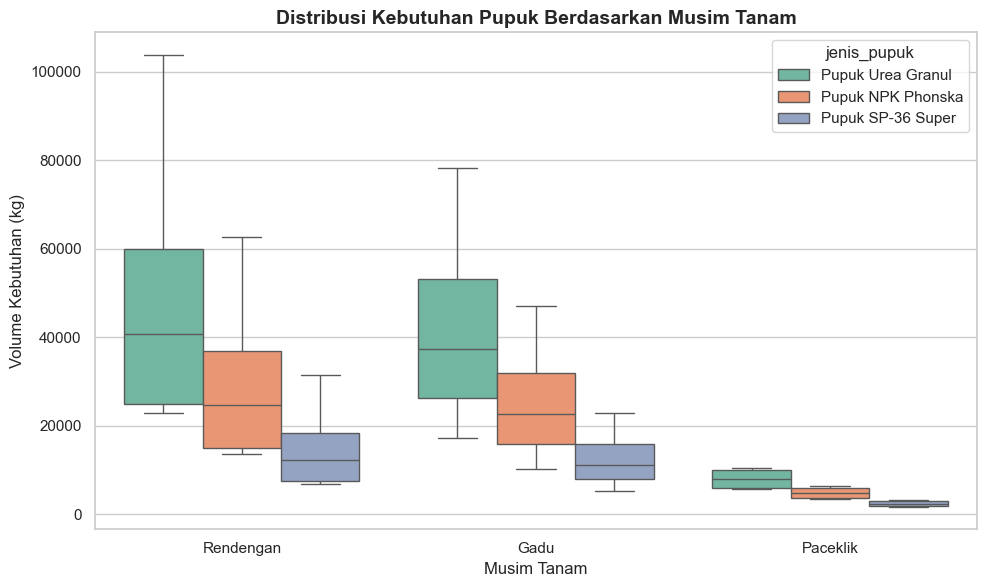

In [5]:
# Grafik 1: Distribusi Kebutuhan Pupuk Berdasarkan Musim Tanam
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='musim_tanam', y='volume_penyaluran_kg', hue='jenis_pupuk', palette='Set2')
plt.title('Distribusi Kebutuhan Pupuk Berdasarkan Musim Tanam', fontsize=14, fontweight='bold')
plt.xlabel('Musim Tanam')
plt.ylabel('Volume Kebutuhan (kg)')
plt.tight_layout()
plt.show()

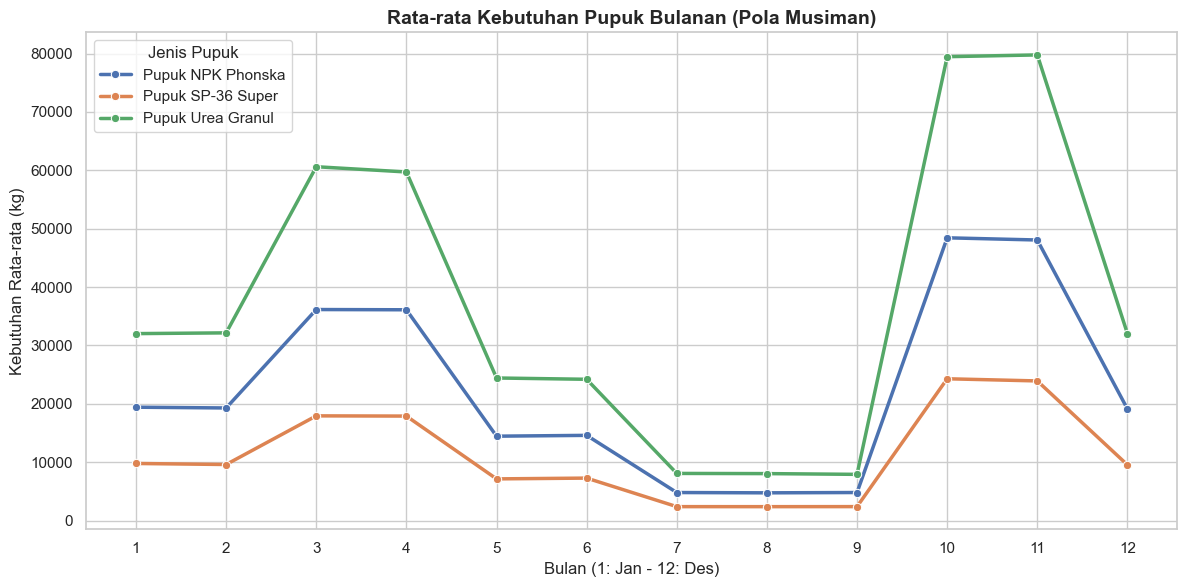

In [6]:
# Grafik 2: Rata-rata Tren Kebutuhan Pupuk Bulanan
monthly_avg = df.groupby(['bulan', 'jenis_pupuk'])['volume_penyaluran_kg'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg, x='bulan', y='volume_penyaluran_kg', hue='jenis_pupuk', marker='o', linewidth=2.5)
plt.title('Rata-rata Kebutuhan Pupuk Bulanan (Pola Musiman)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan (1: Jan - 12: Des)')
plt.ylabel('Kebutuhan Rata-rata (kg)')
plt.xticks(range(1, 13))
plt.legend(title='Jenis Pupuk')
plt.tight_layout()
plt.show()

## 5. Rekayasa Fitur & Pembagian Data (Feature Engineering & Data Split)
Untuk memprediksi kebutuhan masa depan secara aman tanpa masalah ekstrapolasi waktu, fitur 'tahun' dihapus dari dataset pelatihan. Pembagian data dilakukan secara kronologis:
* **Data Latih (Train Set)**: Tahun 2021 hingga 2024.
* **Data Uji (Test Set)**: Tahun 2025 (untuk menguji performa prediksi).

In [7]:
# Tentukan fitur (X) dan label target (y)
# Catatan: Fitur 'tahun' dihapus untuk kestabilan prediksi jangka panjang
X = df[['bulan', 'id_koperasi', 'jenis_pupuk', 'curah_hujan_mm', 'musim_tanam', 'luas_lahan_hektar']]
y = df['volume_penyaluran_kg']

# Split time-based menggunakan kolom tahun asli dari dataset
X_train = X[df['tahun'] < 2025]
y_train = y[df['tahun'] < 2025]
X_test = X[df['tahun'] == 2025]
y_test = y[df['tahun'] == 2025]

print('Jumlah data latih (2021-2024):', X_train.shape[0], 'baris')
print('Jumlah data uji (2025):', X_test.shape[0], 'baris')

Jumlah data latih (2021-2024): 288 baris
Jumlah data uji (2025): 72 baris


## 6. Pelatihan Model Gradient Boosting (Teroptimasi)
Menggunakan model `GradientBoostingRegressor` dengan parameter ter-tuning hasil evaluasi untuk meminimalkan error dan mencegah overfitting.

In [8]:
# 1. Definisikan pemroses kolom kategori
categorical_features = ['id_koperasi', 'jenis_pupuk', 'musim_tanam']
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# 2. Definisikan pipeline model utuh dengan GradientBoostingRegressor teroptimasi
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        min_samples_leaf=4,
        min_samples_split=2,
        random_state=42
    ))
])

# 3. Latih model
model_pipeline.fit(X_train, y_train)
print('Model Gradient Boosting berhasil dilatih!')

Model Gradient Boosting berhasil dilatih!


## 7. Evaluasi Model & Pembanding Train vs Test
Membandingkan R2 Score di data latih dan data uji untuk melihat performa generalisasi model.

In [9]:
# Prediksi
y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

# Metrik evaluasi
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
accuracy_test = 100 - mape_test

print('=== EVALUASI GENERALISASI MODEL ===')
print('R2 Score (Data Train Latih) :', round(r2_train, 4))
print('R2 Score (Data Test Uji)   :', round(r2_test, 4))
print('Mean Absolute Error (Test)  :', round(mae_test, 2), 'kg')
print('Akurasi Model pada Test     :', round(accuracy_test, 2), '%')
print('====================================')
if (r2_train - r2_test) > 0.05:
    print('PERINGATAN: Selisih skor > 5%. Model mungkin mengalami overfitting.')
else:
    print('AMAN: Selisih skor < 5%. Model terbukti tidak mengalami overfitting!')

=== EVALUASI GENERALISASI MODEL ===
R2 Score (Data Train Latih) : 0.9992
R2 Score (Data Test Uji)   : 0.9889
Mean Absolute Error (Test)  : 1212.12 kg
Akurasi Model pada Test     : 93.84 %
AMAN: Selisih skor < 5%. Model terbukti tidak mengalami overfitting!


## 8. Validasi Silang Runtun Waktu & Kurva Pembelajaran (Learning Curve)
Melakukan validasi silang berbasis runtun waktu (*Time-Series Cross Validation*) dan menggambar kurva pembelajaran (*Learning Curve*).

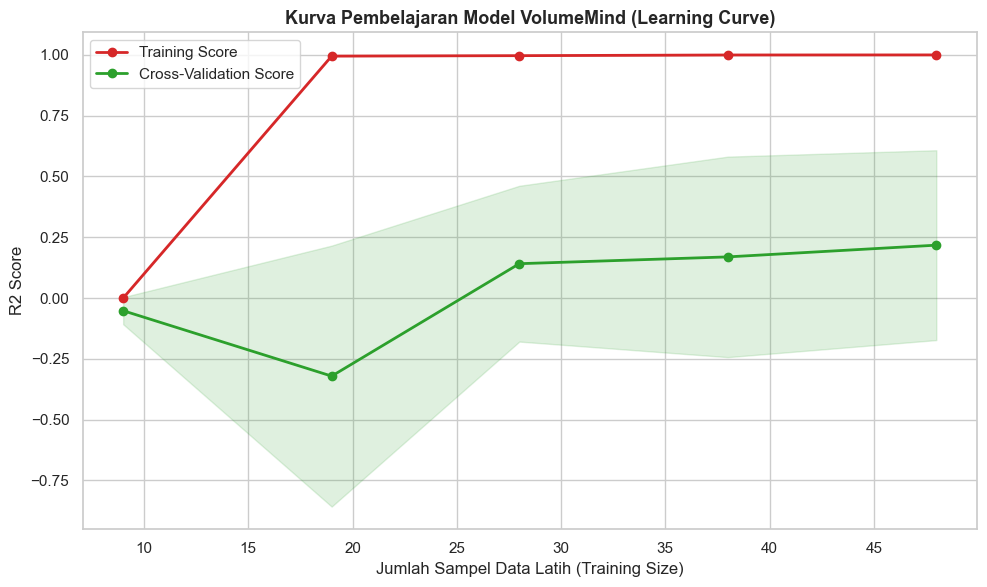

In [10]:
# 1. Time-Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# 2. Membuat Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_pipeline, 
    X_train, 
    y_train, 
    cv=tscv, 
    scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 5),
    random_state=42
)

# Hitung rata-rata dan deviasi standar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 3. Plot Grafik Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#d62728', linewidth=2, label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='#2ca02c', linewidth=2, label='Cross-Validation Score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#d62728')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#2ca02c')

plt.title('Kurva Pembelajaran Model VolumeMind (Learning Curve)', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Sampel Data Latih (Training Size)')
plt.ylabel('R2 Score')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

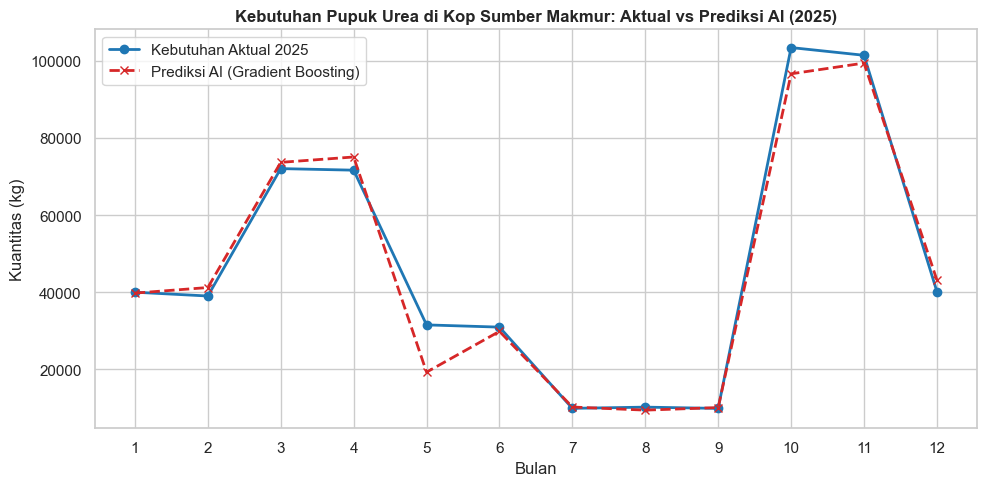

In [11]:
# Grafik 4: Visualisasi Perbandingan Nilai Aktual vs Prediksi Model pada tahun 2025
eval_df = X_test.copy()
eval_df['Aktual'] = y_test
eval_df['Prediksi'] = y_test_pred
eval_df = eval_df.sort_values(by='bulan')

# Ambil contoh untuk Koperasi 'Koperasi Sumber Makmur' dan pupuk 'Pupuk Urea Granul' (disesuaikan dengan nilai riil dataset)
sample_df = eval_df[(eval_df['id_koperasi'] == 'Koperasi Sumber Makmur') & (eval_df['jenis_pupuk'] == 'Pupuk Urea Granul')]

plt.figure(figsize=(10, 5))
plt.plot(sample_df['bulan'], sample_df['Aktual'], label='Kebutuhan Aktual 2025', marker='o', linewidth=2, color='#1f77b4')
plt.plot(sample_df['bulan'], sample_df['Prediksi'], label='Prediksi AI (Gradient Boosting)', marker='x', linestyle='--', linewidth=2, color='#d62728')
plt.title('Kebutuhan Pupuk Urea di Kop Sumber Makmur: Aktual vs Prediksi AI (2025)', fontsize=12, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Kuantitas (kg)')
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

## 9. Ekspor Model Pipeline
Simpan pipeline lengkap agar dapat digunakan di REST API backend tanpa mendefinisikan preprocessing ulang.

In [12]:
model_filename = 'demand_forecasting_model.joblib'
joblib.dump(model_pipeline, model_filename)
print('Pipeline model berhasil diekspor sebagai:', model_filename)

Pipeline model berhasil diekspor sebagai: demand_forecasting_model.joblib
